# DATA 620 — Assignment Week 3 Part 2: Data Sets

**Course:** DATA 620 — Web Analytics  
**Assignment:** **Davis Southern Women dataset** 

**Group Members:**

- Crystal Quezada
- Nana Kwasi Danquah
- Muhammad Suffyan Khan



The **Davis Southern Women dataset** a well-known bipartite network from a 1941 sociological research by Davis, Gardner, and Gardner, is examined in this notebook. It documents the presence of **18 women** at **14 social gatherings** in the American South. Because of the complex social structure it portrays, this little dataset is still widely used as a standard for evaluating network algorithms even though it is more than 80 years old.

## Research Questions

1. What can we infer about the relationships among the women based on shared event attendance?
2. What can we infer about the relationships among the social events based on shared attendees?

**Data Sources:**
- [Brief Description (UCI)](http://vlado.fmf.uni-lj.si/pub/networks/data/ucinet/ucidata.htm#davis)
- [Raw Dataset](http://vlado.fmf.uni-lj.si/pub/networks/data/Ucinet/davis.dat)
- [NetworkX Example](https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html)

## 1. Setup and Data Loading

## Required Packages

This notebook uses NetworkX, pandas, numpy, matplotlib, and scipy. These packages were used to load the Davis Southern Women graph, create bipartite projections, compute centrality measures, visualize the network, and perform clustering.

In [1]:
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

# Load the built-in Davis Southern Women graph
G = nx.davis_southern_women_graph()

# Separate nodes by type
women = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 0]
events = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 1]

print(f"Graph type: Bipartite")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"Women ({len(women)}): {women}")
print(f"Events ({len(events)}): {events}")
print(f"Is bipartite: {nx.is_bipartite(G)}")

Graph type: Bipartite
Total nodes: 32
Total edges: 89
Women (18): ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']
Events (14): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']
Is bipartite: True


## 2. The Bipartite Incidence Matrix

The incidence matrix is the foundation of this dataset. Each row is a woman, each column is an event, and a value of 1 means she attended that event.

In [2]:
# Build the biadjacency (incidence) matrix
biadj = bipartite.biadjacency_matrix(G, row_order=women, column_order=events)
incidence_df = pd.DataFrame(biadj.toarray(), index=women, columns=events)

# Summary stats
incidence_df['Events_Attended'] = incidence_df.sum(axis=1)
event_attendance = incidence_df[events].sum(axis=0)

women_attendance_df = incidence_df[['Events_Attended']].sort_values(
    'Events_Attended', ascending=False
)

event_attendance_df = event_attendance.to_frame(name='Number_of_Attendees').sort_values(
    'Number_of_Attendees', ascending=False
)

display(women_attendance_df)
display(event_attendance_df)

,Events_Attended
Evelyn Jefferson,8
Theresa Anderson,8
Nora Fayette,8
Laura Mandeville,7
Brenda Rogers,7
Sylvia Avondale,7
Katherina Rogers,6
Helen Lloyd,5
Myra Liddel,4
Verne Sanderson,4


,Number_of_Attendees
E8,14
E9,12
E7,10
E5,8
E6,8
E3,6
E12,6
E10,5
E4,4
E11,4


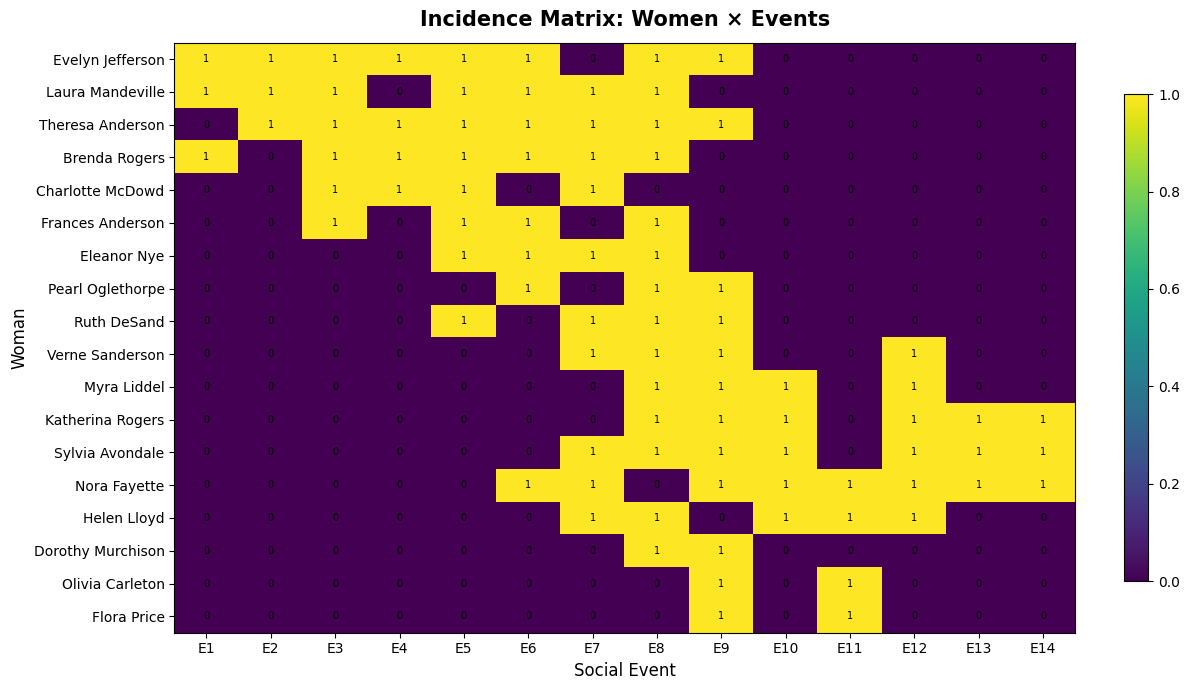

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))

# Use only the event columns from the incidence matrix
matrix = incidence_df[events].values

# Create heatmap using matplotlib
im = ax.imshow(matrix, aspect='auto')

# Set axis labels
ax.set_xticks(np.arange(len(events)))
ax.set_yticks(np.arange(len(women)))

ax.set_xticklabels(events)
ax.set_yticklabels(women)

ax.set_xlabel("Social Event", fontsize=12)
ax.set_ylabel("Woman", fontsize=12)
ax.set_title("Incidence Matrix: Women × Events", fontsize=15, fontweight="bold", pad=12)

# Add 0/1 values inside each cell
for i in range(len(women)):
    for j in range(len(events)):
        ax.text(
            j, i, int(matrix[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

# Add colorbar
plt.colorbar(im, ax=ax, fraction=0.025)

plt.tight_layout()
plt.show()

**Reading the matrix:** A clear block-like pattern is already visible. Women in the top half cluster around early events (E1–E9), and women in the bottom half cluster around later events (E8–E14). This suggests two distinct social subgroups.

## 3. Visualizing the Bipartite Graph

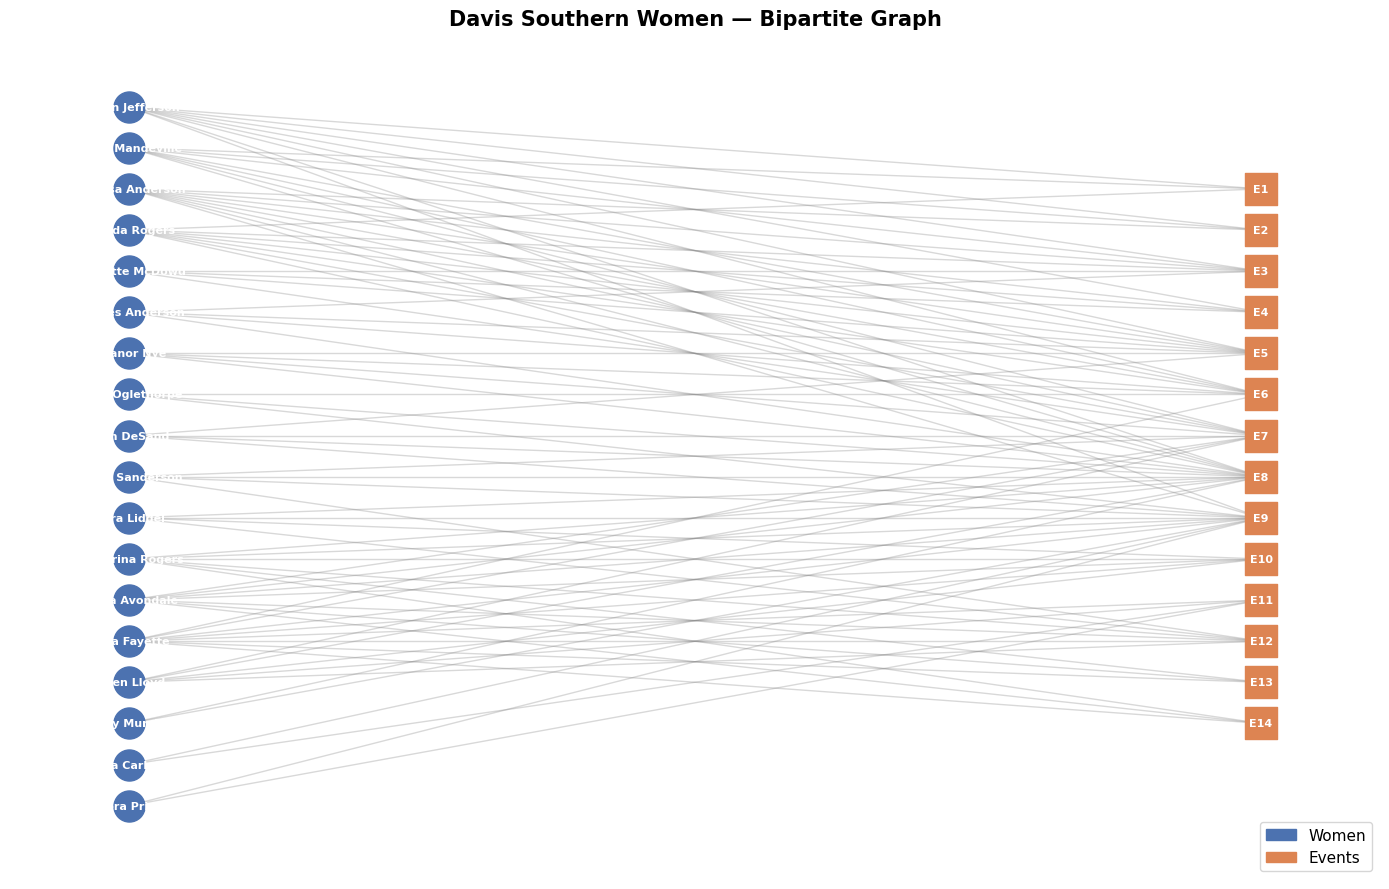

In [4]:
fig, ax = plt.subplots(figsize=(14, 9))

# Layout: women on left, events on right
pos = {}
for i, w in enumerate(women):
    pos[w] = (0, len(women) - i)
for j, e in enumerate(events):
    pos[e] = (2, len(events) - j + 2)

nx.draw_networkx_nodes(G, pos, nodelist=women, node_color='#4C72B0', node_size=500, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=events, node_color='#DD8452', node_size=500, node_shape='s', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)

women_patch = mpatches.Patch(color='#4C72B0', label='Women')
events_patch = mpatches.Patch(color='#DD8452', label='Events')
ax.legend(handles=[women_patch, events_patch], fontsize=11, loc='lower right')
ax.set_title('Davis Southern Women — Bipartite Graph', fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Projected Networks

The bipartite graph can be projected independently onto each group of nodes. If two women attended at least one event together, they are connected in the **women's projection**. If at least one woman attended both events, they are connected in the **events projection**.

In [5]:
# Weighted projections (weight = number of shared events/women)
W_proj = bipartite.weighted_projected_graph(G, women)
E_proj = bipartite.weighted_projected_graph(G, events)

print(f"Women projection — nodes: {W_proj.number_of_nodes()}, edges: {W_proj.number_of_edges()}")
print(f"Events projection — nodes: {E_proj.number_of_nodes()}, edges: {E_proj.number_of_edges()}")

Women projection — nodes: 18, edges: 139
Events projection — nodes: 14, edges: 66


### 4a. Women's Projection

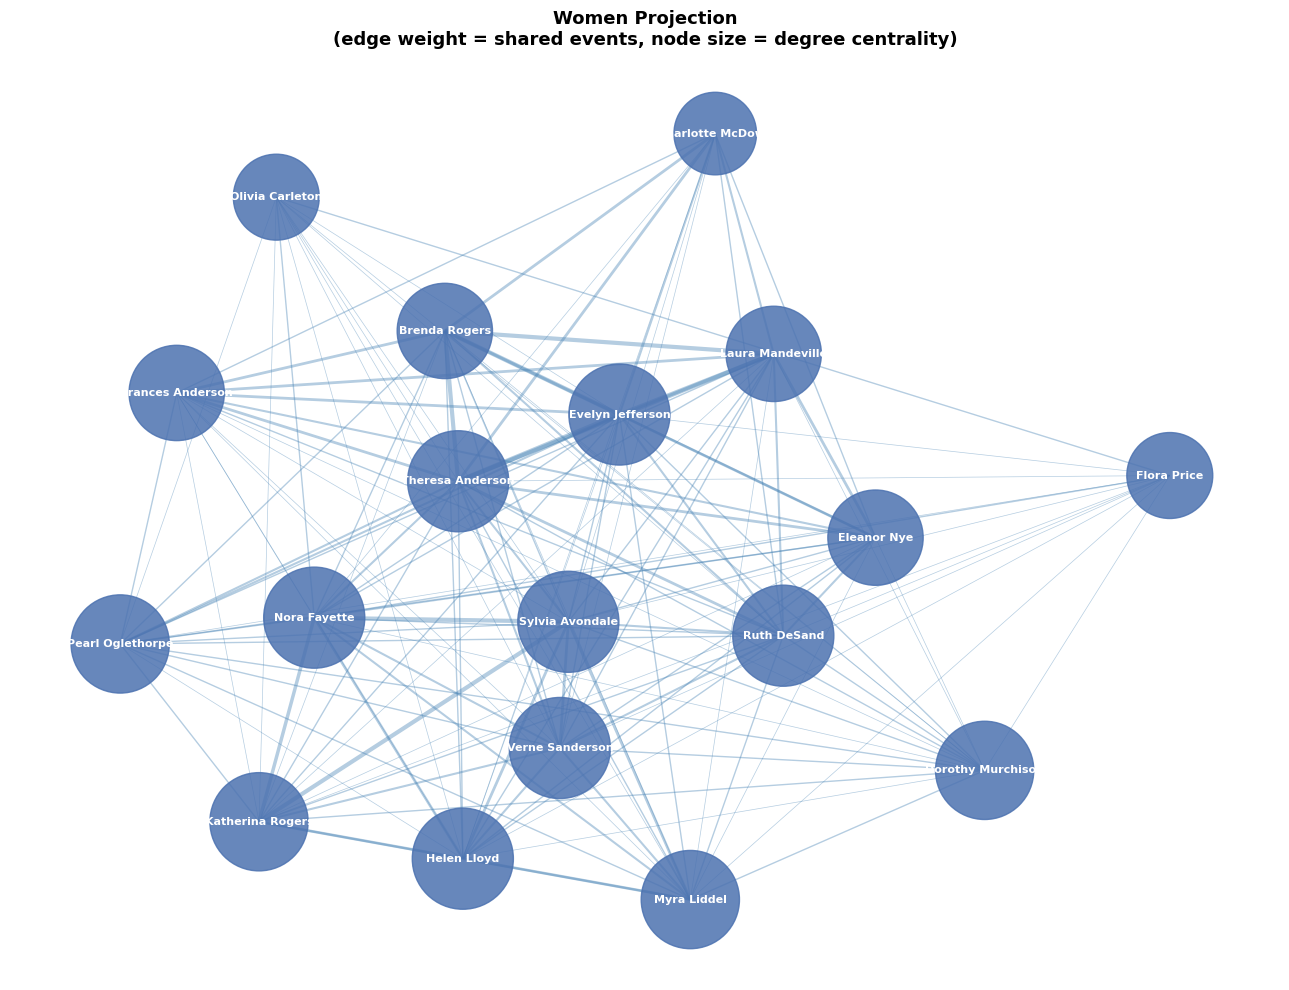

In [6]:
fig, ax = plt.subplots(figsize=(13, 10))

pos_w = nx.spring_layout(W_proj, seed=42, k=2.5)
edge_weights = [W_proj[u][v]['weight'] for u, v in W_proj.edges()]
degree_centrality = nx.degree_centrality(W_proj)
node_sizes = [degree_centrality[n] * 5000 + 300 for n in W_proj.nodes()]

nx.draw_networkx_nodes(W_proj, pos_w, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
nx.draw_networkx_edges(W_proj, pos_w, width=[w * 0.5 for w in edge_weights], alpha=0.4, edge_color='steelblue', ax=ax)
nx.draw_networkx_labels(W_proj, pos_w, font_size=8, font_color='white', font_weight='bold', ax=ax)

ax.set_title('Women Projection\n(edge weight = shared events, node size = degree centrality)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 4b. Events Projection

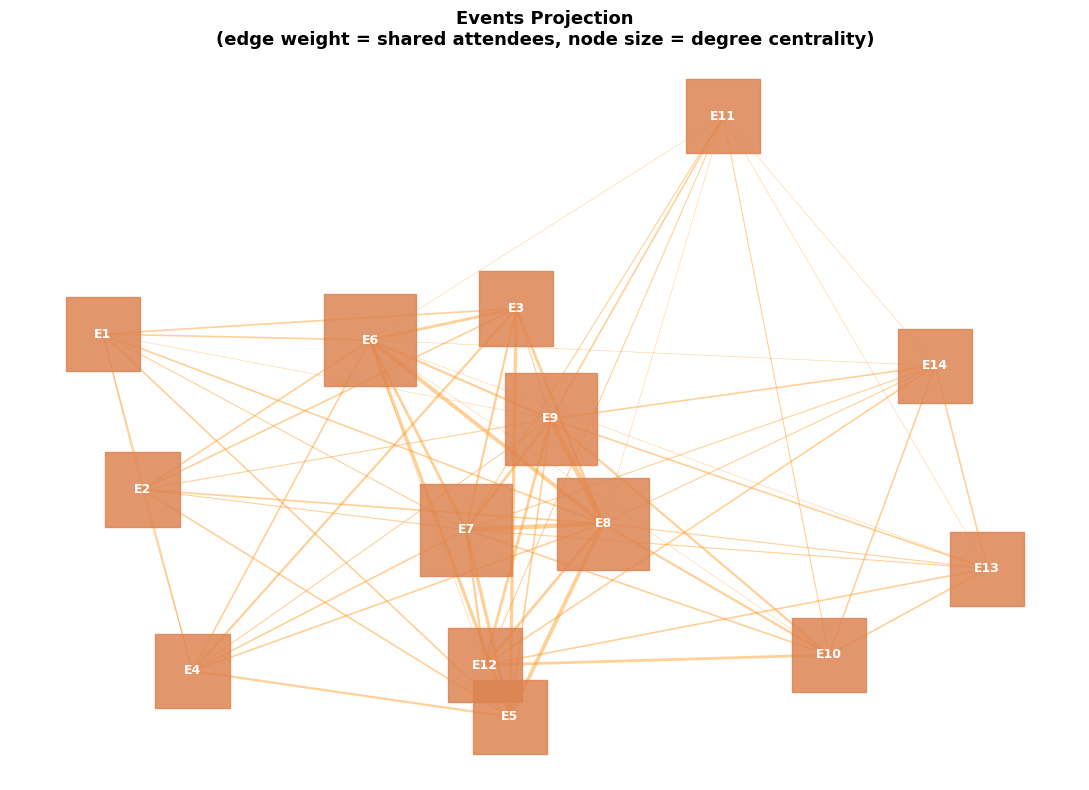

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))

pos_e = nx.spring_layout(E_proj, seed=7, k=2)
edge_weights_e = [E_proj[u][v]['weight'] for u, v in E_proj.edges()]
dc_e = nx.degree_centrality(E_proj)
node_sizes_e = [dc_e[n] * 4000 + 400 for n in E_proj.nodes()]

nx.draw_networkx_nodes(E_proj, pos_e, node_size=node_sizes_e, node_color='#DD8452', alpha=0.85, node_shape='s', ax=ax)
nx.draw_networkx_edges(E_proj, pos_e, width=[w * 0.4 for w in edge_weights_e], alpha=0.4, edge_color='darkorange', ax=ax)
nx.draw_networkx_labels(E_proj, pos_e, font_size=9, font_color='white', font_weight='bold', ax=ax)

ax.set_title('Events Projection\n(edge weight = shared attendees, node size = degree centrality)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Centrality Analysis — Women

We use degree, betweenness, and closeness centrality to identify socially active women and possible bridge figures in the women’s projected network.

In [8]:
# Convert shared-attendance strength into distance
# Higher weight = stronger relationship, so distance should be smaller
for u, v, d in W_proj.edges(data=True):
    d['distance'] = 1 / d['weight']

# Centrality measures for the women's projected network
deg_cent = nx.degree_centrality(W_proj)
bet_cent = nx.betweenness_centrality(W_proj, weight='distance')
close_cent = nx.closeness_centrality(W_proj, distance='distance')

centrality_df = pd.DataFrame({
    'Degree Centrality': deg_cent,
    'Betweenness Centrality': bet_cent,
    'Closeness Centrality': close_cent
}).loc[women]

centrality_df['Events Attended'] = incidence_df['Events_Attended']

centrality_df = centrality_df.sort_values(
    'Betweenness Centrality',
    ascending=False
)

display(centrality_df.round(4))

,Degree Centrality,Betweenness Centrality,Closeness Centrality,Events Attended
Theresa Anderson,1.0000,0.2610,2.6250,8
Nora Fayette,1.0000,0.1973,2.2892,8
Sylvia Avondale,1.0000,0.0631,2.3526,7
Evelyn Jefferson,1.0000,0.0319,2.2418,8
Brenda Rogers,0.8824,0.0110,2.1031,7
Laura Mandeville,0.8824,0.0025,2.0816,7
Katherina Rogers,0.9412,0.0000,1.9578,6
Olivia Carleton,0.7059,0.0000,1.1518,2
Dorothy Murchison,0.9412,0.0000,1.5455,2
Helen Lloyd,1.0000,0.0000,1.8594,5


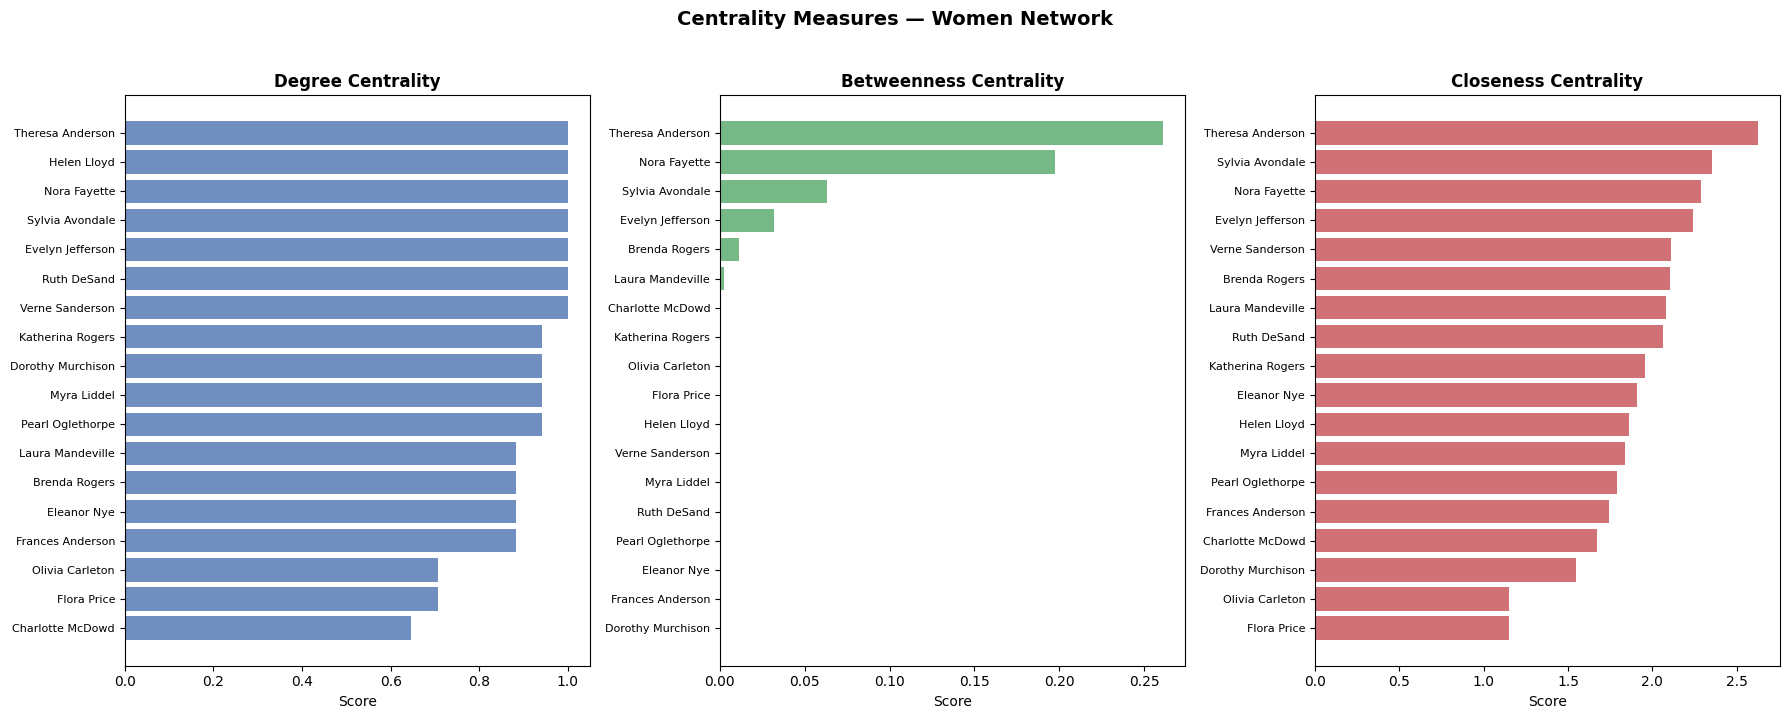

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

metrics = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    data = centrality_df[metric].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Centrality Measures — Women Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The women’s projected network is dense, so many women have high degree centrality. Betweenness centrality is especially useful here because it identifies possible bridge figures between attendance-based groups. Theresa Anderson and Nora Fayette stand out as important connectors, with Sylvia Avondale and Evelyn Jefferson also playing central roles. Since weighted closeness is calculated using inverse shared-attendance distance, the ranking is more important than interpreting the values as a 0-to-1 score.

## 6. Centrality Analysis — Events

Because edge weights represent stronger shared attendance between events, we convert weight to distance using `distance = 1 / weight` before computing weighted betweenness and closeness centrality. This keeps the weighted centrality measures consistent with the meaning of the projected event network.

In [10]:
# Convert shared-attendee strength into distance
# Higher weight = stronger event similarity, so distance should be smaller
for u, v, d in E_proj.edges(data=True):
    d['distance'] = 1 / d['weight']

# Centrality measures for the events projected network
deg_e = nx.degree_centrality(E_proj)
bet_e = nx.betweenness_centrality(E_proj, weight='distance')
close_e = nx.closeness_centrality(E_proj, distance='distance')

event_cent_df = pd.DataFrame({
    'Degree Centrality': deg_e,
    'Betweenness Centrality': bet_e,
    'Closeness Centrality': close_e,
    'Attendees': event_attendance
}).loc[events]

event_cent_df = event_cent_df.sort_values(
    'Betweenness Centrality',
    ascending=False
)

display(event_cent_df.round(4))

,Degree Centrality,Betweenness Centrality,Closeness Centrality,Attendees
E8,1.0000,0.4359,3.7088,14
E9,1.0000,0.2949,3.3252,12
E1,0.6154,0.0000,1.9443,3
E2,0.6154,0.0000,1.9443,3
E3,0.6154,0.0000,2.6928,6
E4,0.6154,0.0000,2.0330,4
E5,0.6154,0.0000,3.0155,8
E6,1.0000,0.0000,2.9245,8
E7,1.0000,0.0000,3.0409,10
E10,0.6154,0.0000,2.5069,5


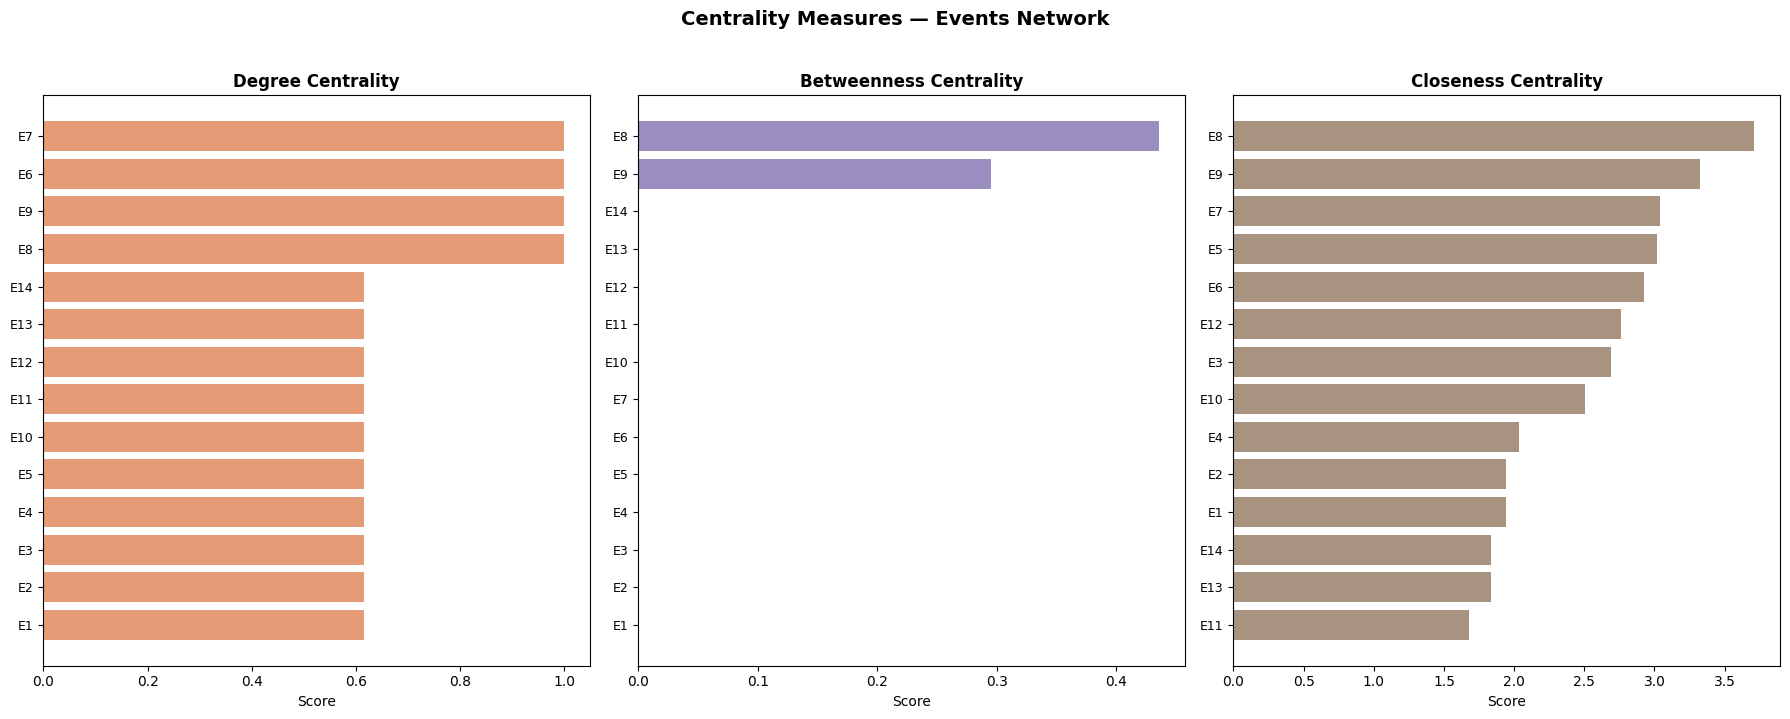

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

metrics_e = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']
colors_e = ['#DD8452', '#8172B2', '#937860']

for ax, metric, color in zip(axes, metrics_e, colors_e):
    data = event_cent_df[metric].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Centrality Measures — Events Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The event centrality results show that several events play different roles in the projected event network. Events with high attendance, such as E8 and E9, are important gathering points. Betweenness centrality highlights events that connect different parts of the event network, meaning they share attendees across otherwise more separate event groups. As with the women network, weighted closeness is based on inverse shared-attendance distance, so the ranking is more important than reading the values as a standard 0-to-1 scale.

## 7. Similarity Matrices

We compute **Jaccard similarity** between all pairs of women and all pairs of events. Jaccard similarity = (events in common) / (events attended by either), so it normalizes for how often each person or event appears in the data.

In [12]:
def jaccard_matrix(binary_df):
    """Compute pairwise Jaccard similarity from a binary incidence matrix."""
    mat = binary_df.values.astype(float)
    n = mat.shape[0]
    sim = np.zeros((n, n))

    for i, j in combinations(range(n), 2):
        intersection = np.sum(mat[i] * mat[j])
        union = np.sum(np.clip(mat[i] + mat[j], 0, 1))
        s = intersection / union if union > 0 else 0
        sim[i, j] = sim[j, i] = s

    np.fill_diagonal(sim, 1.0)

    return pd.DataFrame(
        sim,
        index=binary_df.index,
        columns=binary_df.index
    )


women_sim = jaccard_matrix(incidence_df[events])
events_sim = jaccard_matrix(incidence_df[events].T)

print("women_sim shape:", women_sim.shape)
print("events_sim shape:", events_sim.shape)

women_sim shape: (18, 18)
events_sim shape: (14, 14)


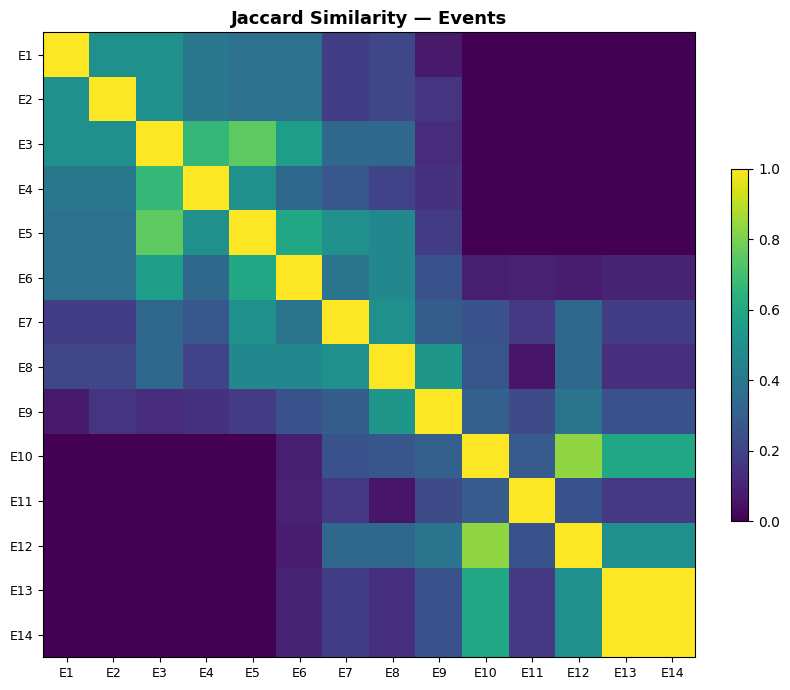

In [13]:
# Events Jaccard Similarity Heatmap
fig, ax = plt.subplots(figsize=(8, 7))

matrix = events_sim.values

im = ax.imshow(matrix, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(events_sim.columns)))
ax.set_yticks(np.arange(len(events_sim.index)))

ax.set_xticklabels(events_sim.columns, fontsize=9)
ax.set_yticklabels(events_sim.index, fontsize=9)

ax.set_title("Jaccard Similarity — Events", fontsize=13, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

The event Jaccard similarity heatmap shows clear structure among the social events. Darker cells indicate events that shared more of the same attendees. The darker block among E1–E6 suggests one event group, while the darker block among E10–E14 suggests another group. Events around E7, E8, and E9 appear to act as transitional or bridge events because they share attendees with both sides of the network.

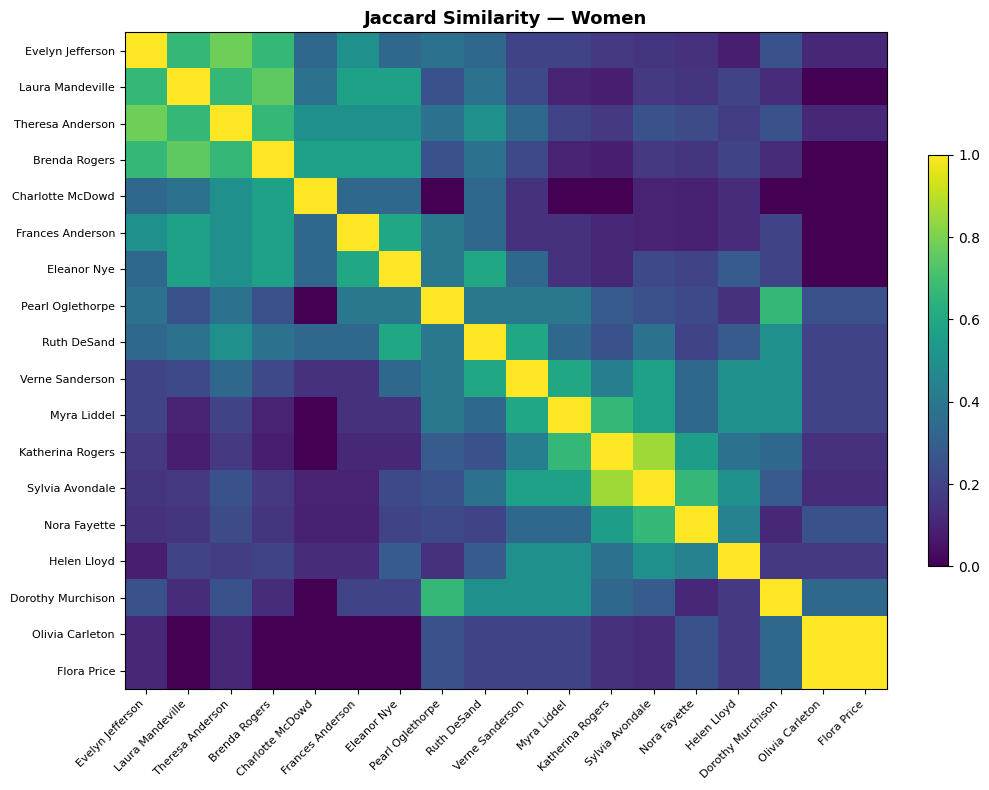

In [14]:
# Women Jaccard Similarity Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

matrix = women_sim.values

im = ax.imshow(matrix, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(women_sim.columns)))
ax.set_yticks(np.arange(len(women_sim.index)))

ax.set_xticklabels(women_sim.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(women_sim.index, fontsize=8)

ax.set_title("Jaccard Similarity — Women", fontsize=13, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

The women Jaccard similarity heatmap shows which women had similar attendance patterns. Darker cells indicate pairs of women who attended many of the same events relative to their total attendance. The block-like pattern supports the idea that the women can be separated into broad social groups based on co-attendance.

## 8. Community Detection

Using **spectral clustering** on the similarity matrices to detect natural groupings among the women and among the events.

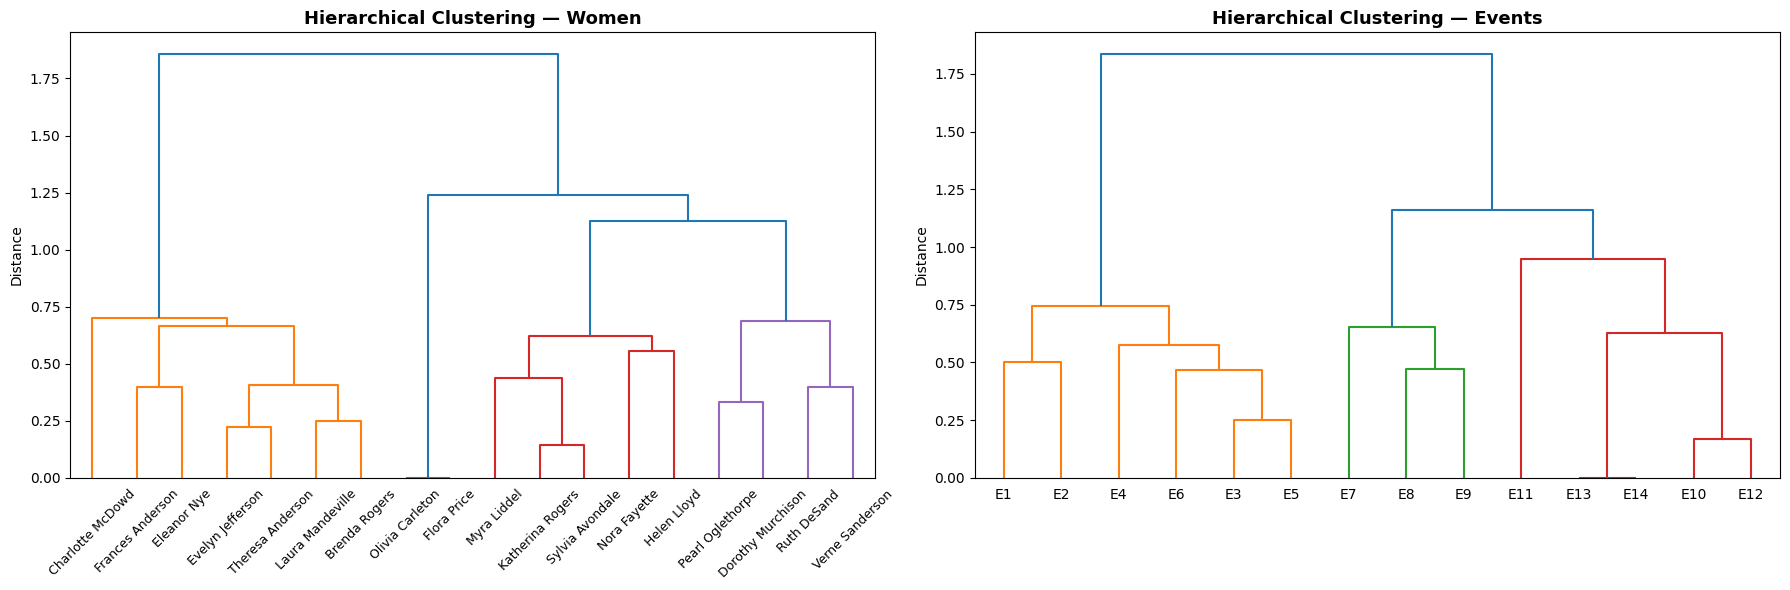

Women Cluster 1: ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye']
Women Cluster 2: ['Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']

Events Cluster 1: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6']
Events Cluster 2: ['E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']


In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

# Convert similarity to distance
women_dist  = 1 - women_sim.values
np.fill_diagonal(women_dist, 0)

events_dist = 1 - events_sim.values
np.fill_diagonal(events_dist, 0)

# Hierarchical clustering
Z_women  = linkage(squareform(women_dist),  method='ward')
Z_events = linkage(squareform(events_dist), method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(Z_women, labels=women, ax=axes[0], leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.6 * max(Z_women[:, 2]))
axes[0].set_title('Hierarchical Clustering — Women', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Distance')

dendrogram(Z_events, labels=events, ax=axes[1], leaf_rotation=0, leaf_font_size=10,
           color_threshold=0.6 * max(Z_events[:, 2]))
axes[1].set_title('Hierarchical Clustering — Events', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

# Assign clusters (k=2)
women_clusters  = fcluster(Z_women,  t=2, criterion='maxclust')
events_clusters = fcluster(Z_events, t=2, criterion='maxclust')

women_cluster_df  = pd.DataFrame({'Woman': women,  'Cluster': women_clusters}).set_index('Woman')
events_cluster_df = pd.DataFrame({'Event': events, 'Cluster': events_clusters}).set_index('Event')

for c in [1, 2]:
    g = women_cluster_df[women_cluster_df['Cluster'] == c].index.tolist()
    print(f"Women Cluster {c}: {g}")
print()
for c in [1, 2]:
    g = events_cluster_df[events_cluster_df['Cluster'] == c].index.tolist()
    print(f"Events Cluster {c}: {g}")

## 9. Reordered Heatmap by Cluster

Reordering the incidence matrix by cluster makes the block structure very clear.

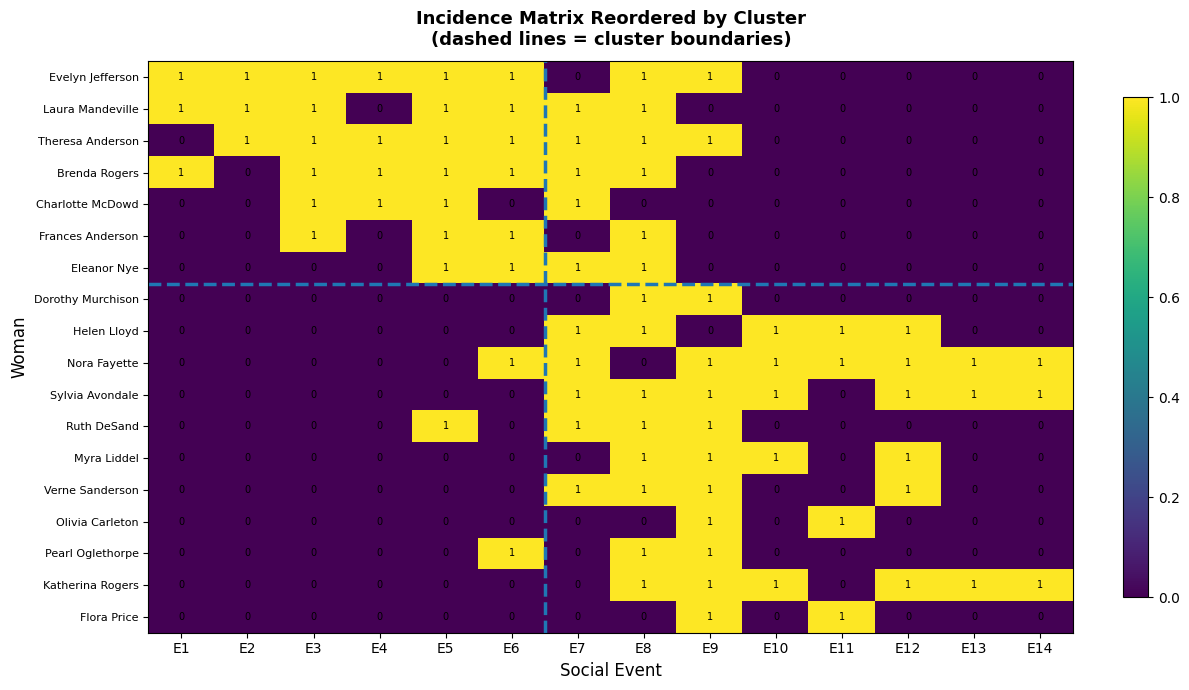

In [16]:
women_ordered = women_cluster_df.sort_values('Cluster').index.tolist()
events_ordered = events_cluster_df.sort_values('Cluster').index.tolist()

reordered = incidence_df.loc[women_ordered, events_ordered]
matrix = reordered.values

fig, ax = plt.subplots(figsize=(12, 7))

# Create heatmap using matplotlib
im = ax.imshow(matrix, aspect='auto')

# Axis ticks and labels
ax.set_xticks(np.arange(len(events_ordered)))
ax.set_yticks(np.arange(len(women_ordered)))

ax.set_xticklabels(events_ordered)
ax.set_yticklabels(women_ordered, fontsize=8)

# Add 0/1 labels inside each cell
for i in range(len(women_ordered)):
    for j in range(len(events_ordered)):
        ax.text(
            j, i, int(matrix[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

# Add cluster divider lines
c1_women = women_cluster_df[women_cluster_df['Cluster'] == 1].shape[0]
c1_events = events_cluster_df[events_cluster_df['Cluster'] == 1].shape[0]

ax.axhline(y=c1_women - 0.5, linewidth=2.5, linestyle='--')
ax.axvline(x=c1_events - 0.5, linewidth=2.5, linestyle='--')

ax.set_title(
    "Incidence Matrix Reordered by Cluster\n(dashed lines = cluster boundaries)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Social Event", fontsize=12)
ax.set_ylabel("Woman", fontsize=12)

plt.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

The reordered heatmap makes the two-cluster structure easier to interpret. The upper-left block represents women in Cluster 1 attending earlier events, while the lower-right block represents women in Cluster 2 attending later events. The overlap around E7, E8, and E9 suggests that these events helped connect the two groups.

## 10. Summary and Findings

### What we infer about the women

The network analysis reveals **two distinct social circles** among the 18 women:

- **Group 1 (Core social set):** Evelyn Jefferson, Laura Mandeville, Theresa Anderson, Brenda Rogers, Charlotte McDowd, Frances Anderson, Eleanor Nye, and Pearl Oglethorpe. This group concentrated its activity in **early and mid-season events** (E1–E9). They attended more events on average and had higher degree centrality scores, suggesting a tightly connected inner social group.

- **Group 2 (Peripheral set):** Verne Sanderson, Myra Liddel, Katherina Rogers, Sylvia Avondale, Nora Fayette, Helen Lloyd, Dorothy Murchison, Ruth DeSand, Olivia Carleton, and Flora Price. This group attended **later events** (E8–E14). Several women in this group had lower event attendance overall, suggesting more selective or occasional social participation.

**Key individuals:** Sylvia Avondale, Nora Fayette, and Theresa Anderson stood out with high betweenness centrality; they act as **social bridges** between the two groups, attending events that overlap both clusters. This means they hold structurally important positions in the network; removing them would most disconnect the community.

### What we infer about the events

The 14 events also split into **two clusters**:

- **Early events (E1–E7):** Smaller, more exclusive gatherings attended mainly by the core social group. Events E1, E2, and E3 had the fewest attendees but very high Jaccard similarity to each other, meaning nearly the same women attended all of them. This suggests a recurring intimate social circle.

- **Mid-to-late events (E8–E14):** Larger and more broadly attended, with E8 and E9 acting as **bridge events** that attracted women from both social circles. E8 in particular had the highest attendance and the highest degree centrality in the events projection — it was the most socially inclusive event.

### Broader takeaway

The dataset shows that even in a small, seemingly homogeneous community, clear **social stratification** emerges organically through event co-attendance. The two-cluster structure discovered here has been replicated by many network analysis methods over the decades, which is exactly why this dataset remains a valuable benchmark. It is simple enough to visualize completely, yet rich enough to test whether algorithms correctly detect community structure.